## 1. Shor Algorithm

Designed to solve the problem of integer factorization—finding the prime numbers that, when multiplied together, produce a specific large number

### 1.1 Problem Statement (with RSA Algorithm)

For example, RSA algorithms picks Prime numbers $p$ and $q$ to form $N = p \times q$. 

Choose $p$, $q$ and $e$ where,

- $\varphi(N) = (p-1)(q-1)$

- $\gcd(e,\varphi(N))=1$

- $d \equiv e^{-1} \pmod{\varphi(N)}$

And then, the Public Key = $(N, e)$, and Private Key = $(N, d)$

3. To encrypt, $c \equiv m^{e} \pmod{N}$.

4. To decrypt, $m \equiv c^{d} \pmod{N}$.

So the goal is to find the parameters of $p$ and $q$ to break the RSA algorithm.

### 1.2 The Solution

If we can factor $N$ into $p$ and $q$, we can mathematically derive the private key $d$ regardless of what $e$ was.

Such that,

- $a^r \equiv 1 \pmod{N}$

And applying the Difference of Squares such that,

- $a^r - 1 = (a^{\frac{r}{2}} - 1)(a^{\frac{r}{2}} + 1)$

In which after the Greatest Common Divisor $gcd$ is used to find the prime numbers,

- $gcd(a^{\frac{r}{2}} - 1, N) = p$
- $gcd(a^{\frac{r}{2}} + 1, N) = q$

For example, say $N = 15$ ($p = 3$ and $q = 5$),

1. Pick a Random Number $a$ that is smaller than $N = 15$ and doesn't share a factor with it. Suppose $a = 7$

2. Figure out how many times we need to multiple $a = 7$ by itself until the remainder becomes $1$.

    > - $7^1 \equiv 7 \pmod{15}$
    > - $7^2 \equiv 4 \pmod{15}$
    > - $7^3 \equiv 13 \pmod{15}$
    > - $7^4 \equiv 1 \pmod{15}$

   Thus concluding $r = 4$ for $a = 7$ such that $7^4 - 1 \equiv 0 \pmod{15}$.

3. Using the Difference of Squares trick, we can rewrite it as
   
   $7^4 - 1 = (7^{\frac{4}{2}} - 1) \times (7^{\frac{4}{2}} + 1) = 48 \times 50$

4. Using the Greatest Common Divisor,

   - For the 1st factor: $gcd(48, 15) = 3$
   - For the 2nd factor: $gcd(50, 15) = 5$

### 1.3 How Quantum speeds things up

##### Classical Algorithm Time Complexity

Using Classical General Number Field Sieve (GNFS) alogrithm, the Time complexity is exponential.

> $T_{classical} \approx e^{1.9 \cdot n^{\frac{1}{3}} (\log n)^{\frac{2}{3}}}$

Using $e^x = 2^{x \cdot \log_2(e)}$, for 2048‑bit $n = 2048$, the work exceeds ($2^{100}$), and adding ~$10$ bits nearly doubles effort.

##### Quantum Algorithm Time Complexity

Using the Shor Algorithm, the Time complexity is polynomial.

> $T_{quantum} \approx n^3$

For 2048 bits, it becomes $2048^3 \approx 8.5\times10^9$ which is much faster.

### 1.4 Quantum Phase Estimation (QPE)

##### Understanding Quantum Fourier Transform (QFT)

Recalling **Fourier Transform** (e.g. visually the waves),

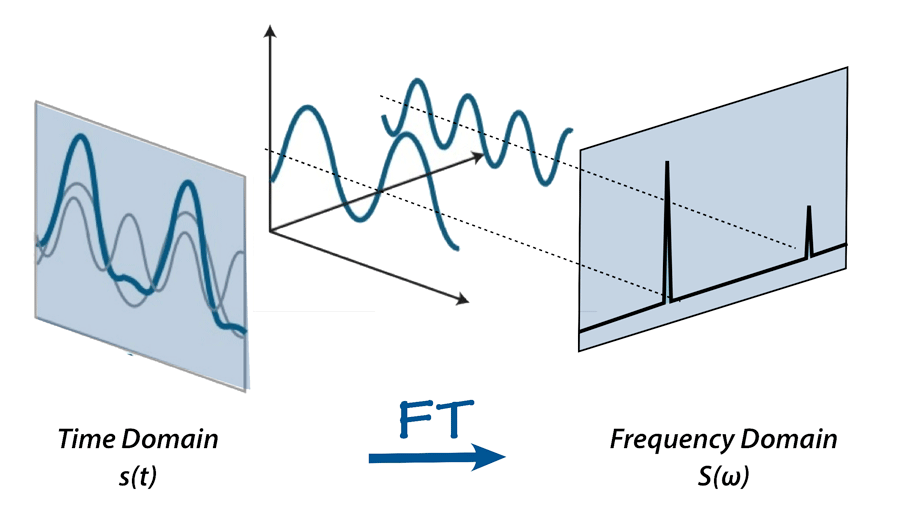

The math for the Classical Fourier Transform (Continuous) looks like this:$$Let's break that down into English:

The mathematical formula is such that,

$F(\omega) = \int_{-\infty}^{\infty} f(t) e^{-i \omega t} dt$

- $f(t)$: This is your Input Signal (the mess of sound/data).

- $e^{-i \omega t}$: This is the "Wrapper." In math, $e^{i\theta}$ is the formula for a circle. By multiplying your signal by this, you are literally wrapping it around a circle at a frequency of $\omega$.

- $\int \dots dt$: This is the "Average." It calculates the center of gravity.

- $F(\omega)$: This is your Output. If $F(\omega)$ is a large number, it means frequency $\omega$ is "present" in the signal.

However for the **Quantum Fourier Transform (QFT)**, it differs as that requires calculating every point in time. For QFT, it uses the Summation version (Discrete Fourier Transform).

$|y\rangle = \frac{1}{\sqrt{N}} \sum_{j=0}^{N-1} e^{2\pi i \frac{jk}{N}} |j\rangle$

This works since the Quantum computer is in a superposition of all $j$ values at once, it performs that "Sum" for all frequencies simultaneously. This is why it scales as $n^2$ instead of the massive classical complexity.

##### How does QFT relates to QPE?

Given the state is $|j\rangle$ only when $j$ is a multiple of $r$, then,

$|j\rangle \rightarrow = |0\rangle, |r\rangle, |2r\rangle, |3r\rangle, \dots$

Thus, instead of summing over every $j$, sum  only over $j = 0, r, 2r, \dots$, then, the exponent becomes: $e^{2\pi i \frac{(mr)k}{N}}$ (where $m$ is just an integer $0, 1, 2...$).

Since $k$ is to be a multiple of $\frac{N}{r}$, then, $\frac{jk}{N} = \frac{(mr) \cdot (\frac{N}{r})}{N} = m$.

This means that whenever $\frac{k}{N}$ is equal to (or very close to) $\frac{1}{r}$, the exponent becomes a whole number. In the world of complex rotations ($e^{2\pi i}$), a whole number means a full 360-degree turn.

Therefore, QPE simplify the target phase to $\theta = \frac{k}{r}$. The "kickback" math in QPE stores the value of the period directly into the phase of the qubit. 

The state of the qubit becomes $|0\rangle + e^{2\pi i (\frac{k}{r})} |1\rangle$, and the QFT then acts as the decoder. It takes that phase ($\frac{k}{r}$) and turns it back into a binary number $k$ that we can read on our screen. Once we read $k$, we know $N$ (we picked it) and we know $\frac{k}{N} \approx \frac{1}{r}$.

Using QPE, the algorithm simply needs to pick $a$ randomly, and it estimates the phase of the unitary matrix, such that,

$U_a|x\rangle = |a x \bmod N\rangle$

The eigenvalues of $U_a$ are $e^{2\pi i \theta} → e^{2\pi i \frac{k}{r}}$, where $r$ is the order of $a \bmod N$, and QPE outputs a number close to $\frac{k}{r}$. 

Using continued fractions where $x = a_0 + \frac{1}{a_1 + \frac{1}{a_2 + \cdots}} \approx \frac{k}{r}$, you recover integer $r$ (where integer $k$ is $(0 \le k < r)$).

##### The Mathematical Description

Since $r$ is the rotation, then $\frac{k}{N} \approx \frac{1}{r}$ can be denoted as $e^{2\pi i j \frac{k}{N}} \approx e^{2\pi i j \theta}$,

1. **State Preparation**: We start with $n$ counting qubits in the $|0\rangle$ state and a target register in the state $|\psi\rangle$. Applying Hadamard gates ($H^{\otimes n}$) to the counting qubits creates a uniform superposition:$$\frac{1}{2^{n/2}} \sum_{j=0}^{2^n-1} |j\rangle |\psi\rangle$$

2. **Controlled-U Operations (Phase Kickback)**: We apply $U$ controlled by the counting qubits, but raised to successive powers of 2. Because of Phase Kickback, the phase is "kicked up" into the counting register:$$\frac{1}{2^{n/2}} \sum_{j=0}^{2^n-1} e^{2\pi i j \theta} |j\rangle |\psi\rangle$$

3. **The Inverse QFT**: The state of the counting qubits now looks like a Fourier-transformed version of the phase. To extract $\theta$, we apply the Inverse Quantum Fourier Transform ($QFT^\dagger$):$$QFT^\dagger \left( \frac{1}{2^{n/2}} \sum_{j=0}^{2^n-1} e^{2\pi i j \theta} |j\rangle \right) = |\tilde{\theta}\rangle$$

4. **Measurement**: Measuring the register gives a bitstring $x$. The estimate for the phase is:$$\theta \approx \frac{x}{2^n}$$

##### Summary of the variables

- $n$: The number of counting qubits (determines the precision). 
- $U$: The unitary operator whose phase we want to find.
- $\theta$: The unknown phase value we are "estimating."

In [9]:
import math
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator

class ShorAlgorithm:
    def __init__(self, N, a):
        self.N = N
        self.a = a
        # For N=15, we need 8 counting qubits for precision 
        # and 4 qubits to hold the number 15 (2^4 = 16)
        self.n_count = 8 
        self.n_target = 4
        self.qc = QuantumCircuit(self.n_count + self.n_target, self.n_count)

    def modular_exponentiation(self):
        """Adds the controlled modular multiplication gates to the circuit."""
        # Start the target register in state |1>
        self.qc.x(self.n_count) 
        
        # Apply controlled-U gates for Phase Estimation
        for q in range(self.n_count):
            # We apply a^(2^q) mod N
            # For N=15, we use a specialized gate (see helper below)
            self.qc.append(self.get_amod15(self.a, 2**q), 
                           [q] + [i + self.n_count for i in range(self.n_target)])

    def get_amod15(self, a, power):
        """Helper to create the U gate for a^power mod 15."""
        U = QuantumCircuit(4)        
        for _ in range(power):
            if a in [2, 13]:
                U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
            if a in [7, 8]:
                U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
            if a == 11:
                U.swap(0, 2); U.swap(1, 3)
            if a in [13, 11, 8]:
                for j in range(4): U.x(j)
        return U.to_gate(label=f"{a}^{power} mod {self.N}").control()

    def compute(self):
        # 1. Superposition
        self.qc.h(range(self.n_count))
        
        # 2. Modular Exponentiation
        self.modular_exponentiation()
        
        # 3. Inverse QFT (The core of Phase Estimation)
        self.qc.append(QFT(self.n_count, inverse=True).to_gate(), range(self.n_count))
        
        # 4. Measure
        self.qc.measure(range(self.n_count), range(self.n_count))
        
        # 5. Simulate
        backend = AerSimulator()
        t_qc = transpile(self.qc, backend)
        return backend.run(t_qc).result().get_counts()

# --- Execution ---
shor = ShorAlgorithm(N=15, a=7)
counts = shor.compute()
print("Measured Phases:", counts)

Measured Phases: {'00000000': 273, '11000000': 236, '01000000': 230, '10000000': 285}


/var/folders/td/rtvtvvjn3x1gfqswnc7bb6hm0000gn/T/ipykernel_16172/807974054.py:51: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  self.qc.append(QFT(self.n_count, inverse=True).to_gate(), range(self.n_count))
